## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

## Dados

`fx_new.csv` — FX diário (Jan/2010 → Mai/2026, unidade local/USD)  
`rates_new.csv` — taxas overnight mensais  
`rates_2y.csv` — yields 2Y mensais

In [2]:
fx       = pd.read_csv("data_rates_cpi/fx_new.csv",   index_col="Date", parse_dates=["Date"], dayfirst=True)
rates    = pd.read_csv("data_rates_cpi/rates_new.csv", index_col="Date", parse_dates=["Date"], dayfirst=True)
rates_2y = pd.read_csv("rates_2y.csv",                index_col="Date", parse_dates=["Date"])

G10 = ["EUR", "GBP", "JPY", "CHF", "AUD", "CAD", "SEK"]

## Fator 1 — Momentum

Sinal diário: `log(FX_{t-21} / FX_{t-63})`, reamostrado para mensal (fim de mês).

In [3]:
momentum_m = (np.log(fx.shift(21) / fx.shift(62))
              .dropna()
              .resample("ME").last())
momentum_m.index = momentum_m.index.to_period("M")

## Fator 2 — Hike Expectations

Slope = yield 2Y − taxa overnight (pontos percentuais). Proxy de expectativa de alta de juros.

In [4]:
r2y_m  = rates_2y.resample("ME").last()
r2y_m.index = r2y_m.index.to_period("M")

rt_m   = rates.resample("ME").last()
rt_m.index = rt_m.index.to_period("M")

hike_s = pd.DataFrame(index=r2y_m.index, dtype=float)
for c in G10:
    hike_s[c] = r2y_m[f"RATE_2Y_{c}"] - rt_m[f"RATE{c}"]

## Retornos Mensais (USD)

`log(FX_{t-1} / FX_t)` — positivo quando moeda local aprecia.

In [5]:
fx_me = fx[G10].resample("ME").last()
fx_me.index = fx_me.index.to_period("M")
ret_m = np.log(fx_me.shift(1) / fx_me)

## Alinhamento e Z-Score Cross-Sectional

In [6]:
common = (momentum_m.index
          .intersection(hike_s.index)
          .intersection(ret_m.index))

def zcs(df):
    mu = df.mean(axis=1)
    sd = df.std(axis=1) + 1e-9
    return df.subtract(mu, axis=0).divide(sd, axis=0)

MOM = zcs(momentum_m.loc[common, G10].astype(float)).values
HIK = zcs(hike_s.loc[common, G10].astype(float)).values
RET = ret_m.loc[common, G10].astype(float).values
T   = len(common)

print(f"Período: {common[0]} -> {common[-1]}  ({T} meses)")

Período: 2010-03 -> 2026-05  (195 meses)


## Walk-Forward OOS

Janela de treino: **60 meses**. A cada mês, 2 000 simulações Monte Carlo amostram `wh ~ Uniform[0,1]` e escolhem o peso de Hike que maximiza o Sharpe in-sample. Portfólio long/short dollar-neutral.

In [7]:
TRAIN = 60
N_MC  = 2000
np.random.seed(42)

def sharpe_np(comp, ret):
    pos = comp.copy()
    ls = np.where(pos > 0,  pos, 0).sum(axis=1, keepdims=True); ls[ls == 0] = 1
    ss = np.where(pos < 0, -pos, 0).sum(axis=1, keepdims=True); ss[ss == 0] = 1
    pos = np.where(pos > 0, pos / ls, np.where(pos < 0, pos / ss, 0))
    pnl = (pos[:-1] * ret[1:]).sum(axis=1)
    std = pnl.std()
    return pnl.mean() / std * np.sqrt(12) if std > 0 else -np.inf

wf_pnl = []
wf_w   = []

for i in range(TRAIN, T - 1):
    tr = slice(i - TRAIN, i)
    m_tr = MOM[tr]; h_tr = HIK[tr]; r_tr = RET[tr]

    WH = np.random.uniform(0, 1, size=N_MC)
    best_sh, best_wh = -np.inf, 0.5
    for k in range(N_MC):
        sh = sharpe_np(WH[k] * h_tr + (1 - WH[k]) * m_tr, r_tr)
        if sh > best_sh:
            best_sh, best_wh = sh, WH[k]

    row = (best_wh * HIK[i] + (1 - best_wh) * MOM[i]).copy()
    ls = row[row > 0].sum(); ss = row[row < 0].sum()
    if ls  > 0: row[row > 0] /=  ls
    if -ss > 0: row[row < 0] /= -ss

    wf_pnl.append({"date": common[i + 1], "pnl": (row * RET[i + 1]).sum()})
    wf_w.append(  {"date": common[i + 1], "wh":  best_wh, "wm": 1 - best_wh})

wf   = pd.DataFrame(wf_pnl).set_index("date")["pnl"]
wf_w = pd.DataFrame(wf_w).set_index("date")

## Resultados OOS

In [8]:
sr   = wf.mean() / wf.std() * np.sqrt(12)
hit  = (wf > 0).mean()
cum  = (1 + wf).cumprod()
dd   = (cum / cum.cummax() - 1).min()
ann  = (1 + wf.mean()) ** 12 - 1

SEP = "=" * 52
print(SEP)
print(f"  G10 Mom+Hike  |  Walk-Forward OOS")
print(SEP)
print(f"  Período:     {wf.index[0]}  ->  {wf.index[-1]}")
print(f"  Meses OOS:   {len(wf)}")
print(f"  Sharpe:      {sr:+.4f}")
print(f"  Hit Rate:    {hit:.1%}")
print(f"  Max DD:      {dd:.1%}")
print(f"  Return/yr:   {ann:.1%}")
print(f"  Hike weight: {wf_w.wh.mean():.3f}   Momentum: {wf_w.wm.mean():.3f}")
print(SEP)

  G10 Mom+Hike  |  Walk-Forward OOS
  Período:     2015-04  ->  2026-05
  Meses OOS:   134
  Sharpe:      +0.4256
  Hit Rate:    54.5%
  Max DD:      -15.4%
  Return/yr:   2.6%
  Hike weight: 0.229   Momentum: 0.771


## Performance Acumulada

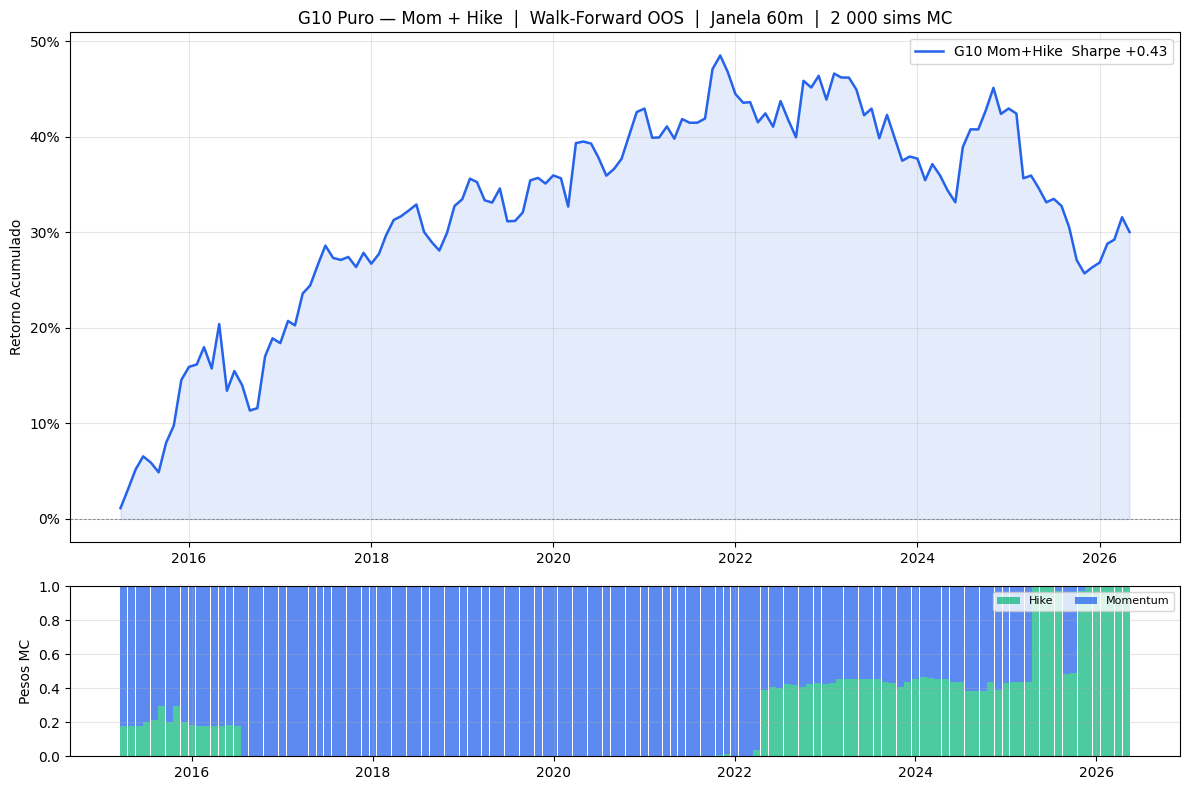

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8),
                         gridspec_kw={"height_ratios": [3, 1]})
ax1, ax2 = axes

cum_pct = (cum - 1) * 100
ax1.plot(cum.index.to_timestamp(), cum_pct.values,
         color="#2563EB", lw=1.8, label=f"G10 Mom+Hike  Sharpe {sr:+.2f}")
ax1.axhline(0, color="gray", lw=0.6, ls="--")
ax1.fill_between(cum.index.to_timestamp(), cum_pct.values, 0,
                 alpha=0.12, color="#2563EB")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax1.set_ylabel("Retorno Acumulado")
ax1.set_title("G10 Puro — Mom + Hike  |  Walk-Forward OOS  |  Janela 60m  |  2 000 sims MC")
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

ax2.bar(wf_w.index.to_timestamp(), wf_w.wh.values,
        color="#10B981", alpha=0.75, width=28, label="Hike")
ax2.bar(wf_w.index.to_timestamp(), wf_w.wm.values,
        bottom=wf_w.wh.values,
        color="#2563EB", alpha=0.75, width=28, label="Momentum")
ax2.set_ylim(0, 1)
ax2.set_ylabel("Pesos MC")
ax2.legend(ncol=2, fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("g10_final_backtest.png", dpi=150, bbox_inches="tight")
plt.show()

## Posicionamento Atual (último mês OOS)

In [10]:
last_mom = MOM[-1]
last_hik = HIK[-1]
last_wh  = wf_w.wh.iloc[-1]
last_wm  = wf_w.wm.iloc[-1]

composite = last_wh * last_hik + last_wm * last_mom
ls = composite[composite > 0].sum(); ss = -composite[composite < 0].sum()
if ls  > 0: composite[composite > 0] /=  ls
if -ss > 0: composite[composite < 0] /= -ss

pos_df = pd.DataFrame({
    "Momentum":  last_mom,
    "Hike":      last_hik,
    "Composite": last_wh * last_hik + last_wm * last_mom,
    "Position":  composite,
}, index=G10).round(3)

pos_df["Side"] = pos_df["Position"].apply(
    lambda x: "LONG" if x > 0.01 else ("SHORT" if x < -0.01 else "NEUTRAL"))

print(f"Pesos: Hike={last_wh:.3f}  Momentum={last_wm:.3f}  (mês: {wf_w.index[-1]})")
print()
print(pos_df.to_string())

Pesos: Hike=0.999  Momentum=0.001  (mês: 2026-05)

     Momentum   Hike  Composite  Position   Side
EUR    -0.614  0.856      0.855     0.285   LONG
GBP    -0.974  1.030      1.028     0.343   LONG
JPY     1.393 -1.292     -1.290    -1.290  SHORT
CHF     1.001 -0.982     -0.980    -0.980  SHORT
AUD    -1.228 -0.540     -0.540    -0.540  SHORT
CAD    -0.049  1.117      1.116     0.372   LONG
SEK     0.471 -0.189     -0.189    -0.189  SHORT
